# Spam Email Classifier

This project uses Machine Learning to classify SMS messages as Spam or Not Spam.

Importing libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

Load Dataset

In [22]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Data Exploration

In [23]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


label
ham     4825
spam     747
Name: count, dtype: int64

Data Cleaning

In [24]:
df['label'] = df['label'].map({'spam':1, 'ham':0})
df.isnull().sum()

label    0
text     0
dtype: int64

Visualization

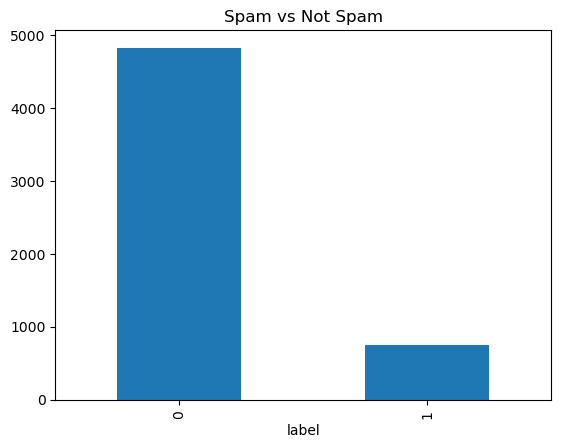

In [29]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Not Spam")
plt.show()

Text Processing

In [30]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['label']

Model Training

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Evaluation

In [32]:
print("Accuracy:", model.score(X_test, y_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))

Accuracy: 0.97847533632287
Confusion Matrix:
 [[939  15]
 [  9 152]]


Prediction

In [33]:
text = ["Free entry in a contest"]
vec = vectorizer.transform(text)

result = model.predict(vec)
print("Spam" if result[0] == 1 else "Not Spam")

Spam
